In [2]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import jax.numpy as jnp

In [3]:
# description = {
#         "task": "MaternEncoder",
#         "l": 4,
#         "var": 2.25,
#         "learning_rate": 3e-4,
#         "architecture": "Simple MLP for both networks",
#         "learnable std": False,
#         "vec_env": 4096,
#         "batchsize": 9192,
#         "rollout_length": 64,
#         "iterations": 20000,
#         "epoch": 4,
#     }

# description_text = "\n".join(
#     [f"{i}: {j}" for i, j in description.items()]
# )

In [4]:
horizon = 3
P_position = np.zeros((1 + horizon * 3, 1 + horizon * 3))
for i in range(1 + horizon): # v positions
    P_position[i, 3 * i] = 1

for i in range(2 * horizon): # s positions
    P_position[1 + horizon + i, 1 + i % 2 + (i // 2) * 3] = 1

In [5]:
print(P_position)

[[1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1. 0.]]


In [6]:
[0, 4, 5, 1, 6, 7, 2, 8, 9, 3]

[0, 4, 5, 1, 6, 7, 2, 8, 9, 3]

In [7]:
t1 = 0.5
t2 = 1
horizon = 3
s_t = np.reshape(
        np.array([t1, t2]) + np.arange(horizon).reshape(-1, 1) * t2,
        (-1,))
print(s_t)


0.5, 1.0, 1.5, 2.0, 2.5, 3.0

[0.5 1.  1.5 2.  2.5 3. ]


(0.5, 1.0, 1.5, 2.0, 2.5, 3.0)

In [8]:
(np.arange(horizon) * t2 + np.array([[t1], [t2]])).shape

(2, 3)

In [16]:
x = np.arange(10)
kernel = jnp.array([0.1, 0.2, 0.4, 0.2, 0.1])

# Apply the convolution. 
# mode='same' ensures the output is the same length as the input
smoothed_signal = jnp.convolve(x, kernel, mode='same')

In [17]:
padded_signal = jnp.pad(x, pad_width=2, mode='edge')
smoothed_signal = jnp.convolve(padded_signal, kernel, mode='valid')

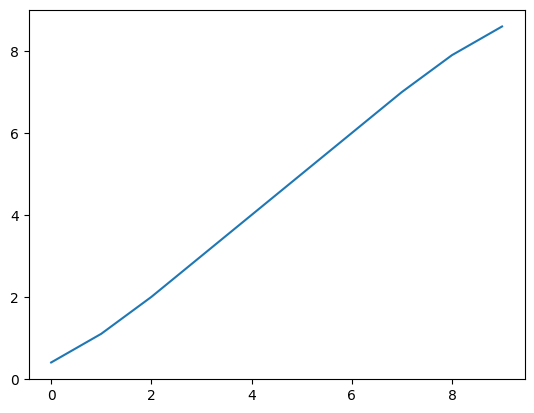

In [18]:
plt.plot(x, smoothed_signal)
plt.show()